## 미니프로젝트


In [40]:
import pandas as pd
import numpy as np

car_df = pd.read_csv("cars.csv")
brand_df = pd.read_csv("brand.csv")

car_df.head(), brand_df.head()


(            title  Price  Mileage(miles)  Registration_Year  Previous Owners  \
 0     SKODA FABIA   6900           70189               2016              3.0   
 1  VAUXHALL CORSA   1495           88585               2008              4.0   
 2     HYUNDAI I30    949          137000               2011              NaN   
 3      MINI HATCH   2395           96731               2010              5.0   
 4  VAUXHALL CORSA   1000           85000               2013              NaN   
 
   Fuel type  Body type Engine Gearbox  Doors  Seats Emission Class  \
 0    Diesel  Hatchback   1.4L  Manual    5.0    5.0         Euro 6   
 1    Petrol  Hatchback   1.2L  Manual    3.0    5.0         Euro 4   
 2    Petrol  Hatchback   1.4L  Manual    5.0    5.0         Euro 5   
 3    Petrol  Hatchback   1.4L  Manual    3.0    4.0         Euro 4   
 4    Diesel  Hatchback   1.3L  Manual    5.0    5.0         Euro 5   
 
   Service history  
 0             NaN  
 1            Full  
 2             NaN  


주데이터와 보조데이터를 불러와 분석준비, head로 데이터가 정상적으로 로드되었는지 확인 

## Step 1-1 데이터 합치기


In [41]:
car_df["brand"] = car_df["title"].str.split().str[0].str.lower()


title 컬럼에서 공백 기준으로 브랜드명을 추출하고,  
brand.csv와의 결합을 위해 소문자로 통일한다.



In [42]:
brand_df = brand_df.rename(columns={"title": "brand"})
brand_df["brand"] = brand_df["brand"].str.lower()

brand.csv의 컬럼명을 brand로 통일하고,  
결합 정확도를 위해 소문자로 변환한다.


In [43]:
merged_df = car_df.merge(brand_df, on="brand", how="left")
merged_df[["title", "brand", "country"]].head()



,title,brand,country
0,SKODA FABIA,skoda,Czech Republic
1,VAUXHALL CORSA,vauxhall,United Kingdom
2,HYUNDAI I30,hyundai,South Korea
3,MINI HATCH,mini,United Kingdom
4,VAUXHALL CORSA,vauxhall,United Kingdom


브랜드를 기준으로 결합, how left는 차량 데이터를 기준으로 유지, 가능한  국가정보를 붙인다.

## 2. 카테고리형 변수를 숫자 형태로 변환하기

In [44]:
merged_df["Engine_code"] = merged_df["Engine"].astype("category").cat.codes
merged_df["Emission_code"] = merged_df["Emission Class"].astype("category").cat.codes

merged_df[["Engine","Engine_code","Emission Class","Emission_code"]].head()


,Engine,Engine_code,Emission Class,Emission_code
0,1.4L,6,Euro 6,5
1,1.2L,4,Euro 4,3
2,1.4L,6,Euro 5,4
3,1.4L,6,Euro 4,3
4,1.3L,5,Euro 5,4


Engine와 Emission Class는 범주형 데이터이므로  
분석을 위해 숫자 형태로 변환하였다.  
원본 컬럼은 유지하고 변환된 값은 _code 컬럼으로 생성하였다.


## 3. 결측치 처리하기

In [45]:
merged_df["Service history"] = merged_df["Service history"].fillna("Unknown")


Service history의 결측치는 정보가 없음을 의미하므로  
'Unknown'으로 채워 결측치를 처리하였다.


In [46]:
merged_df = merged_df.dropna(thresh=len(merged_df.columns) - 2)
merged_df.shape


(3626, 17)

결측치가 과도한 행은 정보가 부족하다고 판단하여 제거하고,  
결측치는 최대 2개까지 허용하였다.

## 4. Scaler 활용해보기 

In [49]:
from sklearn.preprocessing import StandardScaler

# 수치형 컬럼만 선택
num_cols = merged_df.select_dtypes(include=["int64", "float64"]).columns
X = merged_df[num_cols].copy()


X = X.dropna()


X = X.loc[:, X.nunique() > 1]


scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

scaled_data.shape



(2249, 6)

수치형 컬럼만 선택하여 StandardScaler를 적용해  
변수 간 스케일 차이를 보정하였다.


## 5. 기존 데이터의 정보 70% 이상을 가지는 수준에서 최소한의 주성분 추출(PCA)

In [50]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.7)
pca_data = pca.fit_transform(scaled_data)

pca_data.shape


(2249, 3)

PCA를 통해 전체 정보의 70% 이상을 설명하는  
주성분만 남겨 차원을 축소하였다.


## 파트2

### (1) 국가별 총 브랜드의 개수는?

In [51]:
country_brand_cnt = (
    merged_df[["brand", "country"]]
    .dropna()
    .drop_duplicates()
    .groupby("country")
    .size()
    .sort_values(ascending=False)
)

country_brand_cnt


country
Japan             10
United Kingdom     7
Germany            6
United States      5
France             4
Italy              4
South Korea        4
Sweden             2
Czech Republic     1
Malaysia           1
Romania            1
Spain              1
dtype: int64

중복 브랜드를 제거한 뒤,  
국가 기준으로 그룹화하여 브랜드 개수를 집계하였다.


### (2)상관관계가 높은 변수들이 잇는지 확인해보세요

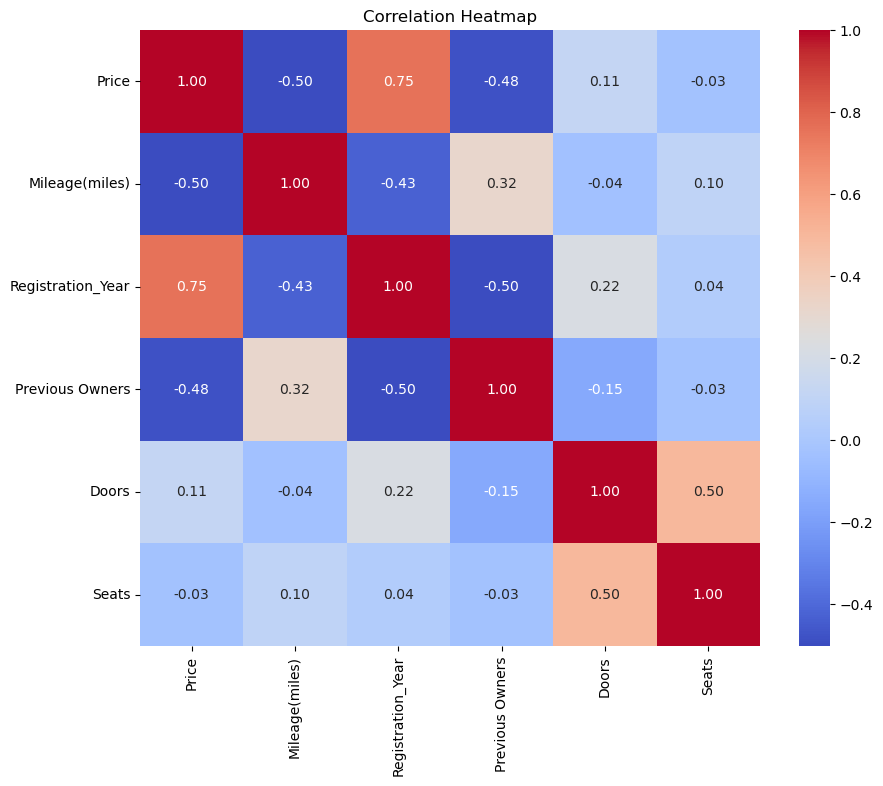

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt


num_df = merged_df.select_dtypes(include=["int64", "float64"])


corr = num_df.corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


수치형 변수 간 상관관계를 확인하기 위해  
상관계수 행렬을 계산하고 히트맵으로 시각화하였다.


## 프로젝트 마무리

본 프로젝트에서는 중고차 가격 데이터와 브랜드 정보를 결합하고,  
범주형 변수 처리, 결측치 처리, 스케일링 및 PCA를 통해  
데이터 전처리 과정을 단계적으로 수행하였다.  
또한 국가별 브랜드 분포와 수치형 변수 간 상관관계를 확인하며  
데이터의 전반적인 특성을 탐색하였다.

